# Model 5a: Innovation Ensemble Model for Imbalanced Classification

Innovation 1 - Ensemble Strategy for Accident Severity Level Classification

💡 Key idea:

Our previous work showed that for the Multi-class classification problem

Traditional Model - XGBoost achieved strong overall accuracy and 
Deep Learning Neural Network model achieved better minority class (Target = 4) recall/precision

Here, we will build a target-aware weighted ensembleensemble model that let

**(1) XGBoost dominate most predictions**

**(2) Neural Network override when it’s confident about class 4**

In [31]:
import os
import json
import pickle
import joblib
import warnings
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support
)

from tensorflow.keras.models import load_model

warnings.filterwarnings("ignore")
np.set_printoptions(suppress=True)
pd.set_option("display.max_columns", 200)

In [32]:
DATA_PATH = "../data/processed/cleaned_data.csv"

XGB_MODEL_PATH = "../models/model1_traditional_ml/xgb_model.pkl"
NN_MODEL_PATH  = "../models/model2_deep_learning/nn_model.h5"

OUTPUT_DIR = "../models/model5_innovation"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [33]:
xgb_model = joblib.load(XGB_MODEL_PATH)
nn_model = load_model(NN_MODEL_PATH)

print("Loaded XGBoost model from:", XGB_MODEL_PATH)
print("Loaded Neural Network model from:", NN_MODEL_PATH)

Loaded XGBoost model from: ../models/model1_traditional_ml/xgb_model.pkl
Loaded Neural Network model from: ../models/model2_deep_learning/nn_model.h5


In [34]:
df = pd.read_csv(DATA_PATH)
print("Data shape:", df.shape)

DROP_COLS = ["Severity", "Target", "Start_Time", "End_Time", "Weather_Timestamp"]
X = df.drop(columns=DROP_COLS).copy()
y = df["Target"].copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("Original target values:", sorted(pd.Series(y).dropna().unique().tolist()))

Data shape: (499290, 257)
Feature matrix shape: (499290, 252)
Target shape: (499290,)
Original target values: [1, 2, 3, 4]


In [35]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Step 1: 70% train, 30% temp
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)


In [37]:
def print_distribution(y_array, name="split"):
    values, counts = np.unique(y_array, return_counts=True)
    pct = counts / counts.sum()
    out = pd.DataFrame({
        "encoded_class": values,
        "count": counts,
        "pct": np.round(pct, 4)
    })
    print(f"\n{name} distribution")
    print(out)

print_distribution(y_train, "train")
print_distribution(y_test, "test")


train distribution
   encoded_class   count     pct
0              0    3483  0.0087
1              1  318135  0.7965
2              2   67231  0.1683
3              3   10583  0.0265

test distribution
   encoded_class  count     pct
0              0    870  0.0087
1              1  79534  0.7965
2              2  16808  0.1683
3              3   2646  0.0265


In [38]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# make them DataFrames to preserve feature names and order
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled  = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

print("Scaled train shape:", X_train_scaled.shape)
print("Scaled test shape: ", X_test_scaled.shape)

Scaled train shape: (399432, 252)
Scaled test shape:  (99858, 252)


In [39]:
# Assumes the most severe original label is the largest class label
severe_original_label = sorted(label_encoder.classes_)[-1]
severe_class_idx = int(label_encoder.transform([severe_original_label])[0])

print("Original classes:", label_encoder.classes_)
print("Severe original label:", severe_original_label)
print("Severe encoded class index:", severe_class_idx)

Original classes: [1 2 3 4]
Severe original label: 4
Severe encoded class index: 3


## Sanity checks on model outputs

In [40]:
print("XGBoost classes_:", getattr(xgb_model, "classes_", "not available"))

xgb_test_probs = xgb_model.predict_proba(X_test_scaled)
nn_test_probs = nn_model.predict(X_test_scaled, verbose=0)

print("xgb_test_probs shape:", xgb_test_probs.shape)
print("nn_test_probs shape: ", nn_test_probs.shape)
print("Unique y_test labels:", np.unique(y_test))

n_classes = len(label_encoder.classes_)
assert xgb_test_probs.shape[1] == n_classes, "XGBoost output columns do not match number of encoded classes."
assert nn_test_probs.shape[1] == n_classes, "NN output columns do not match number of encoded classes."
assert severe_class_idx < n_classes, "Severe class index is out of bounds."

print("Sanity checks passed.")

XGBoost classes_: [0 1 2 3]
xgb_test_probs shape: (99858, 4)
nn_test_probs shape:  (99858, 4)
Unique y_test labels: [0 1 2 3]
Sanity checks passed.


## Helper functions

In [41]:
def ensemble_predict_from_probs(
    xgb_probs,
    nn_probs,
    alpha=0.8,
    boost_factor=1.5,
    threshold_severe=0.25,
    severe_class_idx=3
):
    '''
    Weighted ensemble:
    - blend XGB and NN probabilities
    - optionally boost severe-class probability
    - optionally override to severe class when probability exceeds threshold
    '''
    xgb_probs = np.asarray(xgb_probs)
    nn_probs = np.asarray(nn_probs)

    if xgb_probs.shape != nn_probs.shape:
        raise ValueError(f"Shape mismatch: xgb_probs={xgb_probs.shape}, nn_probs={nn_probs.shape}")

    n_classes = xgb_probs.shape[1]
    if severe_class_idx >= n_classes:
        raise ValueError(f"severe_class_idx={severe_class_idx} but only {n_classes} classes exist.")

    ensemble_probs = alpha * xgb_probs + (1 - alpha) * nn_probs

    # boost the severe class only
    ensemble_probs[:, severe_class_idx] = (
        alpha * xgb_probs[:, severe_class_idx] +
        (1 - alpha) * nn_probs[:, severe_class_idx] * boost_factor
    )

    preds = []
    for i in range(len(ensemble_probs)):
        if ensemble_probs[i, severe_class_idx] >= threshold_severe:
            preds.append(severe_class_idx)
        else:
            preds.append(int(np.argmax(ensemble_probs[i])))

    return np.array(preds), ensemble_probs


def get_one_class_metrics(y_true, y_pred, class_idx):
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=[class_idx],
        average=None,
        zero_division=0
    )
    return {
        "precision": float(precision[0]),
        "recall": float(recall[0]),
        "f1": float(f1[0]),
        "support": int(support[0]),
    }


def build_single_row_dashboard(y_true, y_pred, model_name, severe_class_idx):
    severe = get_one_class_metrics(y_true, y_pred, severe_class_idx)
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(label_encoder.classes_)))

    tp = int(cm[severe_class_idx, severe_class_idx])
    fn = int(cm[severe_class_idx, :].sum() - tp)
    fp = int(cm[:, severe_class_idx].sum() - tp)
    tn = int(cm.sum() - tp - fn - fp)

    return pd.DataFrame([{
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "severe_class_idx": severe_class_idx,
        "severe_original_label": severe_original_label,
        "severe_precision": severe["precision"],
        "severe_recall": severe["recall"],
        "severe_f1": severe["f1"],
        "severe_support": severe["support"],
        "severe_tp": tp,
        "severe_fn": fn,
        "severe_fp": fp,
        "severe_tn": tn
    }])


def plot_confusion_matrix_simple(y_true, y_pred, labels, title):
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(labels)))

    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")

    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

## Evaluate on the test set

In [42]:
xgb_test_probs = xgb_model.predict_proba(X_test_scaled)
nn_test_probs = nn_model.predict(X_test_scaled, verbose=0)

best_alpha = 0.6
best_boost = 1.2
best_threshold = 0.2

ensemble_test_pred, ensemble_test_probs = ensemble_predict_from_probs(
    xgb_probs=xgb_test_probs,
    nn_probs=nn_test_probs,
    alpha=best_alpha,
    boost_factor=best_boost,
    threshold_severe=best_threshold,
    severe_class_idx=severe_class_idx
)

# Baselines
xgb_test_pred = np.argmax(xgb_test_probs, axis=1)
nn_test_pred = np.argmax(nn_test_probs, axis=1)

print("Unique y_test labels:       ", np.unique(y_test))
print("Unique ensemble predictions:", np.unique(ensemble_test_pred))

Unique y_test labels:        [0 1 2 3]
Unique ensemble predictions: [0 1 2 3]


In [43]:
print("=== FINAL ENSEMBLE TEST RESULTS ===")
print(f"Accuracy:    {accuracy_score(y_test, ensemble_test_pred):.4f}")
print(f"Weighted F1: {f1_score(y_test, ensemble_test_pred, average='weighted', zero_division=0):.4f}")
print()
print(classification_report(
    y_test,
    ensemble_test_pred,
    labels=np.arange(len(label_encoder.classes_)),
    target_names=[str(x) for x in label_encoder.classes_],
    zero_division=0
))

=== FINAL ENSEMBLE TEST RESULTS ===
Accuracy:    0.8263
Weighted F1: 0.8129

              precision    recall  f1-score   support

           1       0.77      0.09      0.16       870
           2       0.86      0.94      0.90     79534
           3       0.69      0.41      0.51     16808
           4       0.30      0.41      0.35      2646

    accuracy                           0.83     99858
   macro avg       0.66      0.46      0.48     99858
weighted avg       0.82      0.83      0.81     99858



## Plot Confusion matrix

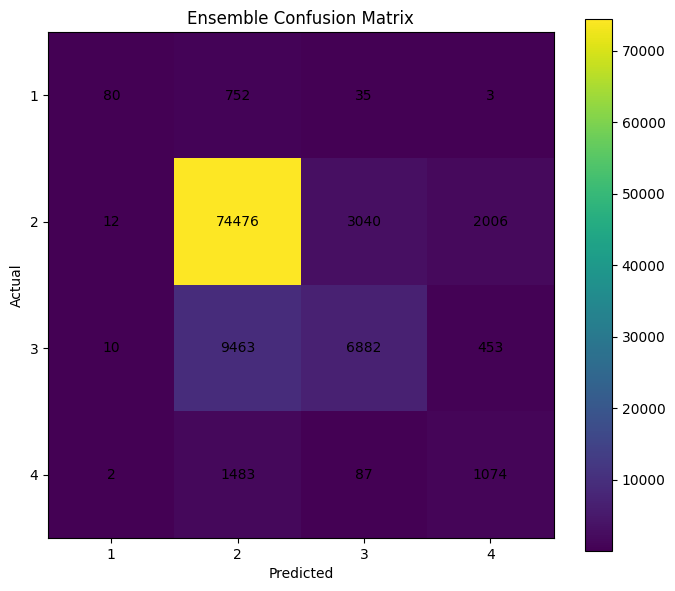

In [44]:
plot_confusion_matrix_simple(
    y_true=y_test,
    y_pred=ensemble_test_pred,
    labels=[str(x) for x in label_encoder.classes_],
    title="Ensemble Confusion Matrix"
)

## Innovation - Severe-class dashboard and model comparison

In [45]:
dashboard_xgb = build_single_row_dashboard(y_test, xgb_test_pred, "XGBoost", severe_class_idx)
dashboard_nn  = build_single_row_dashboard(y_test, nn_test_pred, "Neural Network", severe_class_idx)
dashboard_ens = build_single_row_dashboard(y_test, ensemble_test_pred, "Ensemble", severe_class_idx)

comparison_dashboard = pd.concat(
    [dashboard_xgb, dashboard_nn, dashboard_ens],
    ignore_index=True
)

comparison_dashboard

,model,accuracy,weighted_f1,severe_class_idx,severe_original_label,severe_precision,severe_recall,severe_f1,severe_support,severe_tp,severe_fn,severe_fp,severe_tn
0,XGBoost,0.837770,0.812213,3,4,0.617582,0.106198,0.181232,2646,281,2365,174,97038
1,Neural Network,0.823179,0.805785,3,4,0.493601,0.102041,0.169120,2646,270,2376,277,96935
2,Ensemble,0.826293,0.812850,3,4,0.303733,0.405896,0.347460,2646,1074,1572,2462,94750


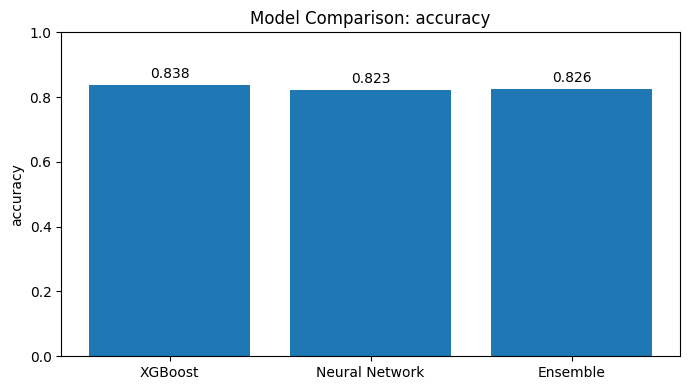

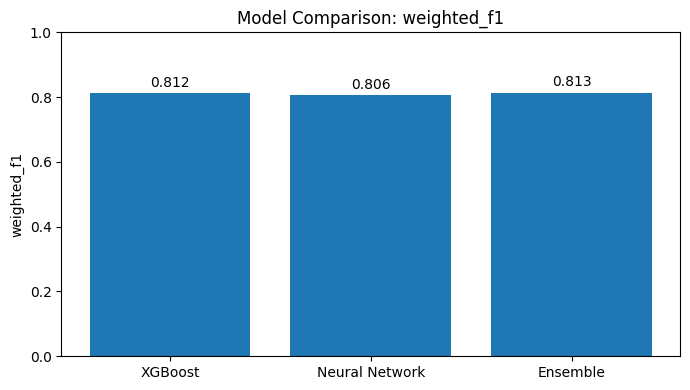

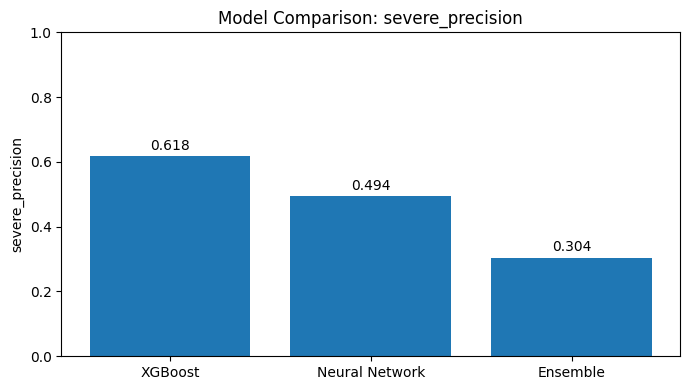

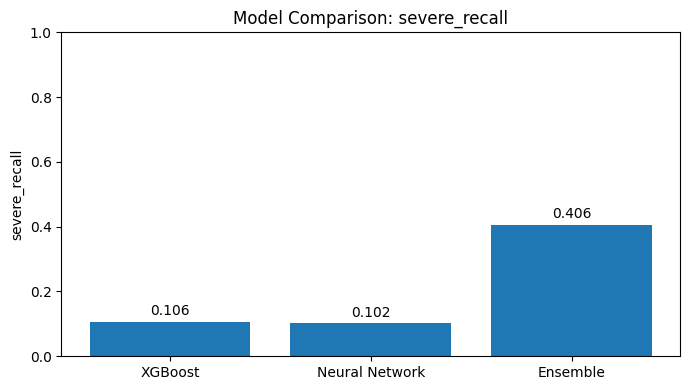

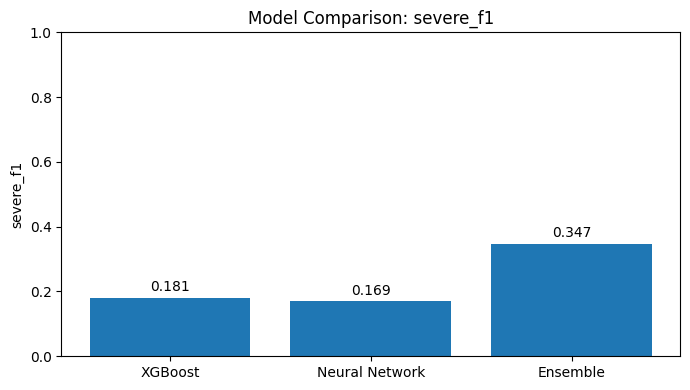

In [46]:
metrics_to_plot = [
    "accuracy",
    "weighted_f1",
    "severe_precision",
    "severe_recall",
    "severe_f1"
]

for metric in metrics_to_plot:
    plt.figure(figsize=(7, 4))
    plt.bar(comparison_dashboard["model"], comparison_dashboard[metric])
    plt.title(f"Model Comparison: {metric}")
    plt.ylabel(metric)
    plt.ylim(0, 1)
    for i, v in enumerate(comparison_dashboard[metric]):
        plt.text(i, min(v + 0.02, 0.98), f"{v:.3f}", ha="center")
    plt.tight_layout()
    plt.show()

## Save final ensemble model

In [47]:
class SafeEnsembleModel:
    def __init__(self, xgb_model, nn_model, scaler, label_encoder, alpha, boost_factor, threshold_severe, severe_class_idx, feature_names):
        self.xgb_model = xgb_model
        self.nn_model = nn_model
        self.scaler = scaler
        self.label_encoder = label_encoder
        self.alpha = alpha
        self.boost_factor = boost_factor
        self.threshold_severe = threshold_severe
        self.severe_class_idx = severe_class_idx
        self.feature_names = feature_names

    def _prepare_X(self, X):
        if isinstance(X, pd.DataFrame):
            X_use = X[self.feature_names].copy()
        else:
            X_use = pd.DataFrame(X, columns=self.feature_names)

        X_scaled = self.scaler.transform(X_use)
        return X_scaled

    def predict_proba(self, X):
        X_scaled = self._prepare_X(X)
        xgb_probs = self.xgb_model.predict_proba(X_scaled)
        nn_probs = self.nn_model.predict(X_scaled, verbose=0)

        ensemble_probs = self.alpha * xgb_probs + (1 - self.alpha) * nn_probs
        ensemble_probs[:, self.severe_class_idx] = (
            self.alpha * xgb_probs[:, self.severe_class_idx] +
            (1 - self.alpha) * nn_probs[:, self.severe_class_idx] * self.boost_factor
        )
        return ensemble_probs

    def predict(self, X):
        probs = self.predict_proba(X)
        preds = []
        for i in range(len(probs)):
            if probs[i, self.severe_class_idx] >= self.threshold_severe:
                preds.append(self.severe_class_idx)
            else:
                preds.append(int(np.argmax(probs[i])))
        return np.array(preds)

    def predict_original_labels(self, X):
        encoded_preds = self.predict(X)
        return self.label_encoder.inverse_transform(encoded_preds)

In [48]:
final_ensemble_model = SafeEnsembleModel(
    xgb_model=xgb_model,
    nn_model=nn_model,
    scaler=scaler,
    label_encoder=label_encoder,
    alpha=best_alpha,
    boost_factor=best_boost,
    threshold_severe=best_threshold,
    severe_class_idx=severe_class_idx,
    feature_names=X.columns.tolist()
)

ensemble_model_path = os.path.join(
    OUTPUT_DIR,
    "model5a_innovation_ensemble_model_for_imbalanced_classification.pkl"
)

with open(ensemble_model_path, "wb") as f:
    pickle.dump(final_ensemble_model, f)

print("Saved final ensemble model to:", ensemble_model_path)

Saved final ensemble model to: ../models/model5_innovation\model5a_innovation_ensemble_model_for_imbalanced_classification.pkl


## Business win of this project:

What Recall Means in this case: For severe accidents (class 4): Recall = True Positives / Actual Severe Cases

Translation: Out of all accidents that impact the traffic the most, how many did we correctly catch?

**Business Interpretation -** 

BEFORE innovation: stand-alone Traditional ML model or Deep Learning NN model only catches 10% of most severe accidents while misses 90% of them

This means response not triggered and safety interventions not deployed

AFTER innovation: recall improves to 0.41

Now the model is catching 41% of severe cases, this is 4x improvement

This will let the city provide more early interventions and better resource allocation. Resulting in reduced downstream cost and improved safety outcomes


**We improved prediction for accidents that impact traffic the most by combining a high-precision XGBoost model with a more sensitive neural network. The ensemble introduces a class-specific threshold and probability boost, allowing us to capture significantly more severe cases without materially degrading overall accuracy. This is critical because the cost of missing a severe event is much higher than a false alarm.**

## Financial Impact

In [58]:
def calculate_roi(
    n_severe_cases,
    recall_before,
    recall_after,
    cost_per_case,
    savings_rate
):
    delta_recall = recall_after - recall_before
    
    additional_cases = n_severe_cases * delta_recall
    savings_per_case = cost_per_case * savings_rate
    total_savings = additional_cases * savings_per_case
    
    return {
        "additional_cases_detected": int(additional_cases),
        "savings_per_case": f"${savings_per_case:,.2f}",
        "total_savings": f"${total_savings:,.2f}"
    }

In [60]:
## in the given dataset, there are approx. 13000 accidents labeled with severity level 4

roi = calculate_roi(
    n_severe_cases=13000,
    recall_before=0.10,
    recall_after=0.406,
    cost_per_case=50000,
    savings_rate=0.20
)

roi

{'additional_cases_detected': 3060,
 'savings_per_case': '$10,000.00',
 'total_savings': '$30,600,000.00'}

## By improving recall from 10% to 40.6%, we captureed 3,060 additional severe cases. Assuming each level 4 traffic cost 50,000 dollars and an early intervention will save 20% of that cost, this improved model will generate approximately $30.6 million in annual savings.

In [22]:
# Example usage later:
#
# import pickle
# with open("../models/model5_innovation/model5a_innovation_ensemble_model_for_imbalanced_classification.pkl", "rb") as f:
#     ensemble_model = pickle.load(f)
#
# preds_encoded = ensemble_model.predict(X_new)
# preds_original = ensemble_model.predict_original_labels(X_new)
#
# print(preds_encoded[:10])
# print(preds_original[:10])